In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

files = {'A1': 'A1.csv', 'A2': 'A2.csv', 'A3': 'A3.csv', 'B1': 'B1.csv', 'B2': 'B2.csv'}
data = {name: pd.read_csv(f).dropna() for name, f in files.items() if pd.io.common.file_exists(f)}

In [47]:
def get_extrapolated_break_with_plot(t, T, t_peak, dt_before_start, dt_before_end, dt_after_start, dt_after_end, name):
    # Linear regression for the liquid phase before the peak
    m1 = (t >= t_peak + dt_before_start) & (t <= t_peak + dt_before_end)
    slope1, int1, _, _, _ = linregress(t[m1], T[m1])
    
    # Linear regression for the solidification phase after the peak
    m2 = (t >= t_peak + dt_after_start) & (t <= t_peak + dt_after_end)
    slope2, int2, _, _, _ = linregress(t[m2], T[m2])
    
    if slope1 == slope2: 
        return T[np.argmin(np.abs(t - t_peak))]
    
    # Get the intersection point of the two tangents
    t_int = (int2 - int1) / (slope1 - slope2)
    T_int = slope1 * t_int + int1
    
    # Plot
    plt.figure(figsize=(8, 6))
    
    # Generate a time range for plotting the tangents
    t_min, t_max = 0, t_int + 2000
    t_line_full = np.linspace(t_min, t_max, 100)
    
    # Plot the tangents
    plt.plot(t_line_full, slope1 * t_line_full + int1, 'r-', linewidth=1.5, alpha=0.6, label=f'Liquid Line (Slope: {slope1:.4f})')
    plt.plot(t_line_full, slope2 * t_line_full + int2, 'b-', linewidth=1.5, alpha=0.6, label=f'Solidification Line (Slope: {slope2:.4f})')
    
    # Plot the original data points
    plt.plot(t, T, 'k.', label='Experimental Data', alpha=0.5)

    # Label the data points used for fitting
    plt.plot(t[m1], T[m1], 'ro', markersize=5, label='Liquid Window Data')
    plt.plot(t[m2], T[m2], 'bo', markersize=5, label='Solid Window Data')
    
    # Label the intersection point
    plt.plot(t_int, T_int, 'g*', markersize=15, label=f'Extrapolated Break = {T_int:.2f} °C')
    
    
    plt.title(f'Tangent Extrapolation for Run {name}', fontsize=14)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Temperature (°C)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(f'{name}_extrapolation_plot.png', dpi=150)
    plt.show() 
    plt.close()
    
    return T_int

In [48]:
def plot_pure_substance_halt_manual(t, T, name, plateau_window):
    start_time, end_time = plateau_window
    
    plateau_mask = (t >= start_time) & (t <= end_time)
    
    T_halt = np.max(T[plateau_mask])
    t_halt = t[plateau_mask][np.argmax(T[plateau_mask])]
        
    plt.figure(figsize=(8, 6))
    plt.plot(t, T, 'k.', label='Experimental Data', alpha=0.5)
    
    # Highlight the plateau
    plt.plot(t[plateau_mask], T[plateau_mask], 'mo', markersize=4, label=f'Plateau Region')
    
    # Plot the pure melting point and the peak recovery point
    plt.axhline(T_halt, color='r', linestyle='--', linewidth=2, label=f'Pure Melting Point = {T_halt:.2f} °C')
    plt.plot(t_halt, T_halt, 'g*', markersize=15, label=f'Peak Recovery Point')

    
    plt.title(f'Run {name}', fontsize=14)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Temperature (°C)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(f'{name}_halt_plot.png', dpi=150)
    plt.show() 
    plt.close()
    
    return T_halt

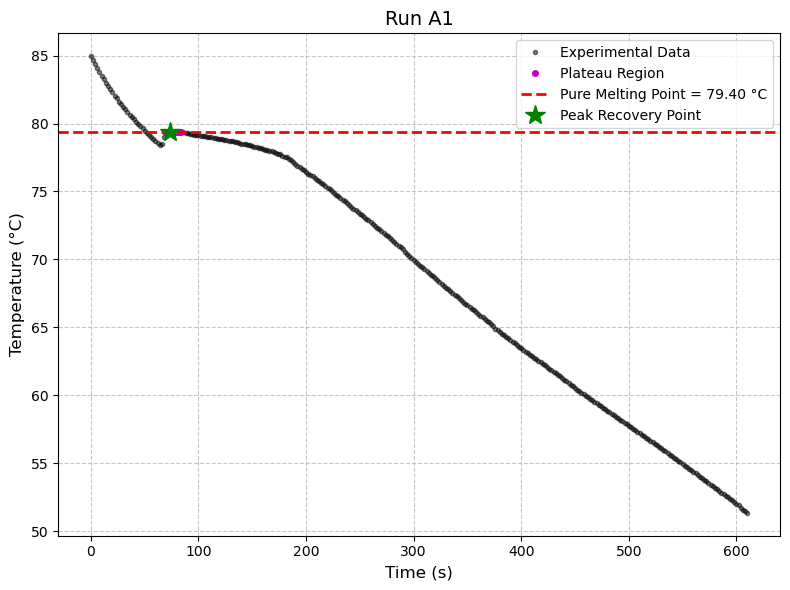

A1: Halt (Peak) = 79.40 °C


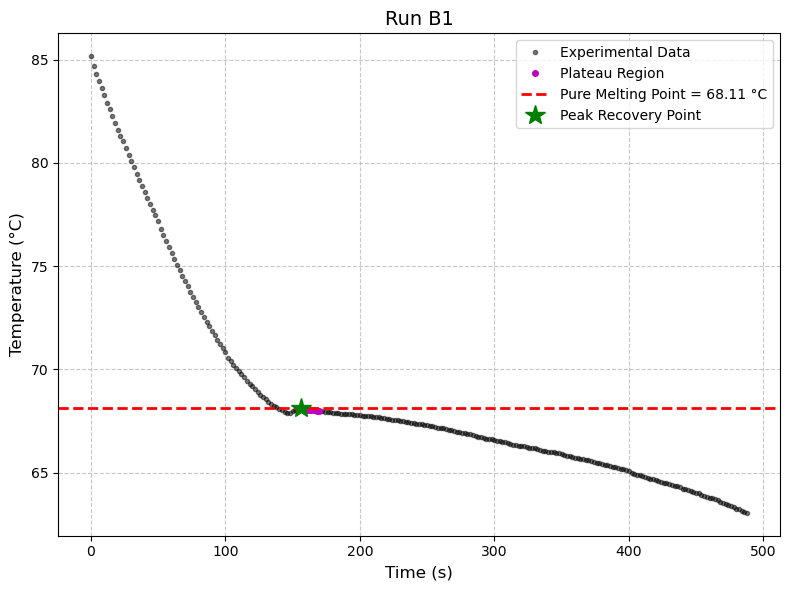

B1: Halt (Peak) = 68.11 °C


In [49]:
# Analysis of pure compound
results = {}
for name, df in data.items():
    t, T = df['Latest: Time (s)'].values, df['Latest: Temperature (°C)'].values
    
    if name == 'A1':
        T_halt = plot_pure_substance_halt_manual(t, T, name, plateau_window=(70, 85))
        results[name] = {'T_halt': T_halt, 'T_break': None}
        print(f"{name}: Halt (Peak) = {T_halt:.2f} °C")
        
    elif name == 'B1':
        T_halt = plot_pure_substance_halt_manual(t, T, name, plateau_window=(155, 170))
        results[name] = {'T_halt': T_halt, 'T_break': None}
        print(f"{name}: Halt (Peak) = {T_halt:.2f} °C")

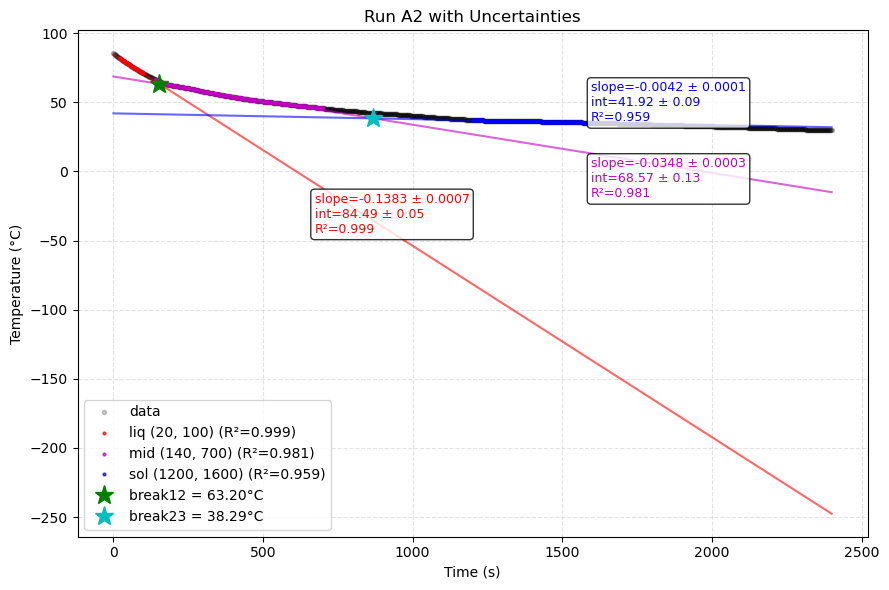

A2: T_break_12=63.20°C, T_break_23=38.29°C, R²=(0.999, 0.981, 0.959), slopes=(-0.138337, -0.034841, -0.004177)


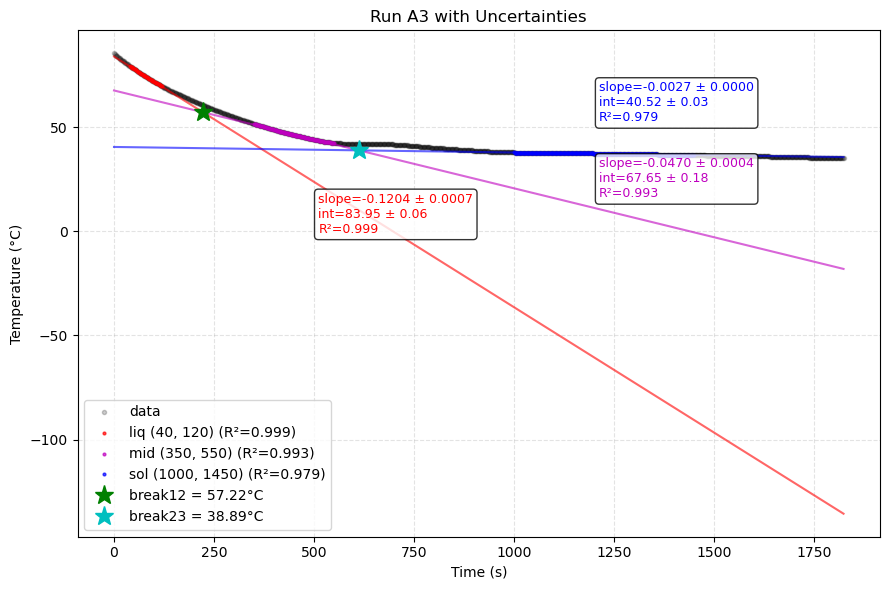

A3: T_break_12=57.22°C, T_break_23=38.89°C, R²=(0.999, 0.993, 0.979), slopes=(-0.12038, -0.046988, -0.002666)


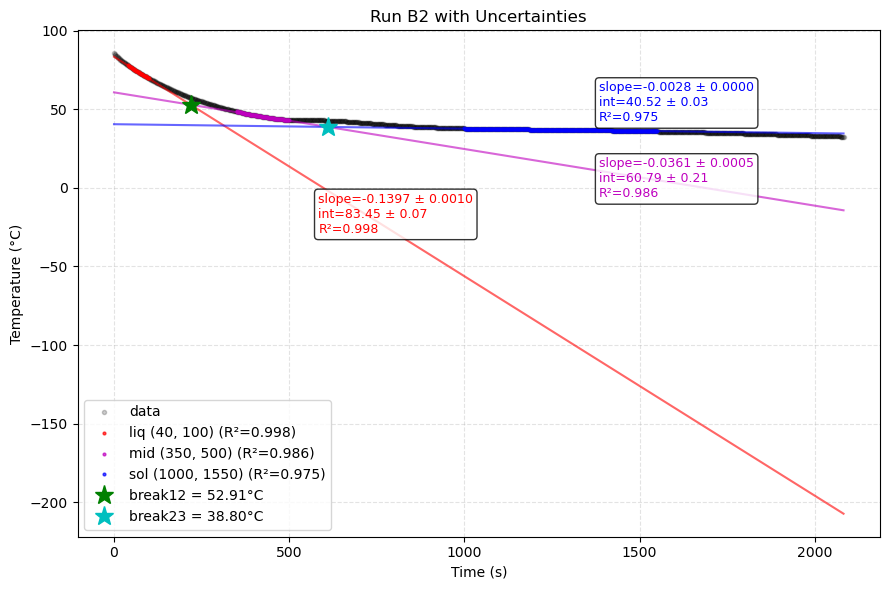

B2: T_break_12=52.91°C, T_break_23=38.80°C, R²=(0.998, 0.986, 0.975), slopes=(-0.139677, -0.036054, -0.002835)


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def _fit_line_in_window(t, T, window, label=""):
    m = (t >= window[0]) & (t <= window[1])
    if np.sum(m) < 2:
        raise ValueError(f"{label} window {window} has <2 points, cannot regress.")
    
    # 提取完整的拟合结果
    res = linregress(t[m], T[m])
    
    # 获取斜率和截距的不确定度 (标准误)
    # 兼容性处理：intercept_stderr 需要 SciPy >= 1.6.0
    se_slope = res.stderr
    se_intercept = getattr(res, 'intercept_stderr', 0.0) 
    
    return res.slope, res.intercept, res.rvalue**2, se_slope, se_intercept, m

def _line_intersection_with_err(s1, b1, err_s1, err_b1, s2, b2, err_s2, err_b2, eps=1e-12):
    if abs(s1 - s2) < eps:
        raise ValueError("Two fitted lines are nearly parallel; intersection is unstable.")
    
    # 计算交点坐标
    t_int = (b2 - b1) / (s1 - s2)
    T_int = s1 * t_int + b1
    
    # 误差传递 (Error Propagation)
    # 假设协方差为0的简化版误差传递公式
    num = b2 - b1
    den = s1 - s2
    var_num = err_b1**2 + err_b2**2
    var_den = err_s1**2 + err_s2**2
    
    if num != 0:
        err_t_int = abs(t_int) * np.sqrt((var_num / num**2) + (var_den / den**2))
    else:
        err_t_int = np.sqrt(var_num) / abs(den)
        
    # 计算 T_int 的误差: T = s1 * t + b1
    err_T_int = np.sqrt((s1 * err_t_int)**2 + (t_int * err_s1)**2 + err_b1**2)
    
    return t_int, T_int, err_t_int, err_T_int

def get_3seg_piecewise_manual(t, T, name, liq_window, mid_window, sol_window, savefig=True):
    t = np.asarray(t, float)
    T = np.asarray(T, float)

    # 包含不确定度的线性回归
    s1, b1, r2_1, err_s1, err_b1, m1 = _fit_line_in_window(t, T, liq_window, label=f"{name} liq")
    s2, b2, r2_2, err_s2, err_b2, m2 = _fit_line_in_window(t, T, mid_window, label=f"{name} mid")
    s3, b3, r2_3, err_s3, err_b3, m3 = _fit_line_in_window(t, T, sol_window, label=f"{name} sol")

    # 寻找带有不确定度的交点
    t12, T12, err_t12, err_T12 = _line_intersection_with_err(s1, b1, err_s1, err_b1, s2, b2, err_s2, err_b2)
    t23, T23, err_t23, err_T23 = _line_intersection_with_err(s2, b2, err_s2, err_b2, s3, b3, err_s3, err_b3)

    # Plot
    t_min = min(liq_window[0], mid_window[0], sol_window[0], t.min())
    t_max = max(liq_window[1], mid_window[1], sol_window[1], t.max())
    t_line = np.linspace(t_min, t_max, 300)

    plt.figure(figsize=(9, 6))
    plt.plot(t, T, 'k.', alpha=0.20, label='data')

    # highlight windows
    plt.plot(t[m1], T[m1], 'ro', markersize=2, alpha=0.7, label=f'liq {liq_window} (R²={r2_1:.3f})')
    plt.plot(t[m2], T[m2], 'mo', markersize=2, alpha=0.7, label=f'mid {mid_window} (R²={r2_2:.3f})')
    plt.plot(t[m3], T[m3], 'bo', markersize=2, alpha=0.7, label=f'sol {sol_window} (R²={r2_3:.3f})')

    # fitted lines
    plt.plot(t_line, s1*t_line + b1, 'r-', alpha=0.6)
    plt.plot(t_line, s2*t_line + b2, 'm-', alpha=0.6)
    plt.plot(t_line, s3*t_line + b3, 'b-', alpha=0.6)

    # intersections (标注加入了不确定度 ±)
    plt.plot(t12, T12, 'g*', markersize=14, label=f'break12 = {T12:.2f}°C')
    plt.plot(t23, T23, 'c*', markersize=14, label=f'break23 = {T23:.2f}°C')

    if not (liq_window[0] <= t12 <= sol_window[1]):
        plt.text(0.02, 0.02, "WARNING: break12 time outside plot range?", transform=plt.gca().transAxes)
    if not (liq_window[0] <= t23 <= sol_window[1]):
        plt.text(0.02, 0.06, "WARNING: break23 time outside plot range?", transform=plt.gca().transAxes)
        
    # Denote uncertainty on the plot using ± format
    text_liq = f'slope={s1:.4f} ± {err_s1:.4f}\nint={b1:.2f} ± {err_b1:.2f}\nR²={r2_1:.3f}'
    text_mid = f'slope={s2:.4f} ± {err_s2:.4f}\nint={b2:.2f} ± {err_b2:.2f}\nR²={r2_2:.3f}'
    text_sol = f'slope={s3:.4f} ± {err_s3:.4f}\nint={b3:.2f} ± {err_b3:.2f}\nR²={r2_3:.3f}'

    plt.text(0.3, 0.6, text_liq, transform=plt.gca().transAxes, color='r', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    plt.text(0.65, 0.67, text_mid, transform=plt.gca().transAxes, color='m', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    plt.text(0.65, 0.82, text_sol, transform=plt.gca().transAxes, color='b', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    plt.title(f'Run {name} with Uncertainties')
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (°C)')
    plt.grid(True, linestyle='--', alpha=0.35)
    plt.legend()
    plt.tight_layout()

    if savefig:
        plt.savefig(f'{name}_manual_3seg_with_err.png', dpi=150)

    plt.show()
    plt.close()

    return {
        "T_break_12": float(T12), "err_T_break_12": float(err_T12),
        "T_break_23": float(T23), "err_T_break_23": float(err_T23),
        "R2": (float(r2_1), float(r2_2), float(r2_3)),
        "slopes": (float(s1), float(s2), float(s3)),
        "err_slopes": (float(err_s1), float(err_s2), float(err_s3))
    }

windows_3seg = {
    'A2': {'liq': (20, 100),  'mid': (140, 700),  'sol': (1200, 1600)},
    'A3': {'liq': (40, 120),  'mid': (350, 550),  'sol': (1000, 1450)},
    'B2': {'liq': (40, 100),  'mid': (350, 500),  'sol': (1000, 1550)},
}

for name in ["A2", "A3", "B2"]:
    df = data[name]
    t = df["Latest: Time (s)"].values
    T = df["Latest: Temperature (°C)"].values

    w = windows_3seg[name]
    out = get_3seg_piecewise_manual(
        t, T, name,
        liq_window=w["liq"],
        mid_window=w["mid"],
        sol_window=w["sol"],
        savefig=True
    )

    results.setdefault(name, {})
    results[name]["T_break"] = out["T_break_12"]   
    results[name]["T_halt"]  = out["T_break_23"]   
    results[name]["T_break_12"] = out["T_break_12"]
    results[name]["T_break_23"] = out["T_break_23"]

    print(
        f"{name}: T_break_12={out['T_break_12']:.2f}°C, "
        f"T_break_23={out['T_break_23']:.2f}°C, "
        f"R²={tuple(round(x,3) for x in out['R2'])}, "
        f"slopes={tuple(round(s,6) for s in out['slopes'])}"
    )

In [51]:
# Thermodynamic Calculations & Error Analysis
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Literature values for comparison
R = 8.314 # J/(mol*K)
MW_A = 128.17 # Naphthalene (g/mol)
MW_B = 154.21 # Biphenyl (g/mol)

T_A_0_lit = 353.4             # K
DeltaH_A_lit = 19.01 * 1000   # J/mol
T_B_0_lit = 342.1             # K
DeltaH_B_lit = 18.57 * 1000   # J/mol
X_BE_lit = 0.540              # Eutectic composition of Biphenyl in the mixture

# Read results from previous analysis
mass_config = {
    'A1': {'mass_A': 5.0017, 'mass_B': 0.00},
    'A2': {'mass_A': 5.0017, 'mass_B': 1.6717},
    'A3': {'mass_A': 5.0017, 'mass_B': 4.1738},
    'B1': {'mass_A': 0.00, 'mass_B': 5.0013},
    'B2': {'mass_A': 1.6706, 'mass_B': 5.0013}
}

data_points = {}
for name, m in mass_config.items():
    if name in results:
        # Pure substances
        if name in ['A1', 'B1']:
            t_liq = results[name]['T_halt']
            t_eut = None
        # Mixture
        else:
            t_liq = results[name]['T_break']
            t_eut = results[name]['T_halt']
            
        data_points[name] = {
            'mass_A': m['mass_A'], 
            'mass_B': m['mass_B'], 
            'T_liq': t_liq, 
            'T_eut': t_eut
        }

# Compute molar fractions and prepare data for linear regression
points = []
for name, d in data_points.items():
    nA = d['mass_A'] / MW_A
    nB = d['mass_B'] / MW_B
    total_n = nA + nB
    XA = nA / total_n
    XB = nB / total_n
    
    T_liq_K = d['T_liq'] + 273.15
    inv_T = 1.0 / T_liq_K
    
    points.append({
        'Run': name, 'XA': XA, 'XB': XB, 
        'T_liq_K': T_liq_K, 'inv_T': inv_T, 
        'ln_XA': np.log(XA) if XA > 0 else None, 
        'ln_XB': np.log(XB) if XB > 0 else None
    })

df_res = pd.DataFrame(points)

# Linear regression and thermodynamic calculations
# Component A (Naphthalene)
df_A = df_res[df_res['Run'].isin(['A1', 'A2', 'A3'])]
slope_A, intercept_A, r_val_A, _, std_err_A = linregress(df_A['inv_T'], df_A['ln_XA'])
DeltaH_A = -slope_A * R
T_A_0 = -slope_A / intercept_A

# Component B (Biphenyl)
df_B = df_res[df_res['Run'].isin(['B1', 'B2'])]
slope_B, intercept_B, r_val_B, _, std_err_B = linregress(df_B['inv_T'], df_B['ln_XB'])
DeltaH_B = -slope_B * R
T_B_0 = -slope_B / intercept_B

# Compute eutectic calculations)
eutectic_temps = [d['T_eut'] for name, d in data_points.items() if d['T_eut'] is not None]
avg_T_eut = np.mean(eutectic_temps)
T_E_K = avg_T_eut + 273.15

# Compute composition at eutectic point using Component B data
ln_XB_E = (DeltaH_B_lit / R) * (1.0/T_B_0_lit - 1.0/T_E_K)
XB_E = np.exp(ln_XB_E)

# Error analysis
err_TA = abs(T_A_0 - T_A_0_lit) / T_A_0_lit * 100
err_dHA = abs(DeltaH_A - DeltaH_A_lit) / DeltaH_A_lit * 100
err_TB = abs(T_B_0 - T_B_0_lit) / T_B_0_lit * 100
err_dHB = abs(DeltaH_B - DeltaH_B_lit) / DeltaH_B_lit * 100
err_XBE = abs(XB_E - X_BE_lit) / X_BE_lit * 100

# Print results
print("="*50)
print("EXPERIMENTAL RESULTS & THERMODYNAMIC DATA")
print("="*50)
print(f" [Component A: Naphthalene]")
print(f" Linear Fit R²   = {r_val_A**2:.4f}")
print(f" Melting Point   = {T_A_0:.2f} K ({T_A_0 - 273.15:.2f} °C)  | Lit: {T_A_0_lit:.2f} K")
print(f" Heat of Fusion  = {DeltaH_A/1000:.2f} kJ/mol         | Lit: {DeltaH_A_lit/1000:.2f} kJ/mol")
print(f" -> T_A_0 Error  : {err_TA:.2f} %")
print(f" -> dH_A Error   : {err_dHA:.2f} %\n")

print(f" [Component B: Biphenyl]")
print(f" Linear Fit R²   = {r_val_B**2:.4f}")
print(f" Melting Point   = {T_B_0:.2f} K ({T_B_0 - 273.15:.2f} °C)  | Lit: {T_B_0_lit:.2f} K")
print(f" Heat of Fusion  = {DeltaH_B/1000:.2f} kJ/mol         | Lit: {DeltaH_B_lit/1000:.2f} kJ/mol")
print(f" -> T_B_0 Error  : {err_TB:.2f} %")
print(f" -> dH_B Error   : {err_dHB:.2f} %\n")

print(f" [Eutectic Point]")
print(f" Avg Temperature = {T_E_K:.2f} K ({avg_T_eut:.2f} °C)")
print(f" Biphenyl Mole%  = {XB_E:.4f}               | Lit: {X_BE_lit:.4f}")
print(f" -> X_BE Error   : {err_XBE:.2f} %")
print("="*50)

EXPERIMENTAL RESULTS & THERMODYNAMIC DATA
 [Component A: Naphthalene]
 Linear Fit R²   = 0.9205
 Melting Point   = 351.42 K (78.27 °C)  | Lit: 353.40 K
 Heat of Fusion  = 21.42 kJ/mol         | Lit: 19.01 kJ/mol
 -> T_A_0 Error  : 0.56 %
 -> dH_A Error   : 12.65 %

 [Component B: Biphenyl]
 Linear Fit R²   = 1.0000
 Melting Point   = 341.26 K (68.11 °C)  | Lit: 342.10 K
 Heat of Fusion  = 20.56 kJ/mol         | Lit: 18.57 kJ/mol
 -> T_B_0 Error  : 0.25 %
 -> dH_B Error   : 10.71 %

 [Eutectic Point]
 Avg Temperature = 311.81 K (38.66 °C)
 Biphenyl Mole%  = 0.5303               | Lit: 0.5400
 -> X_BE Error   : 1.80 %


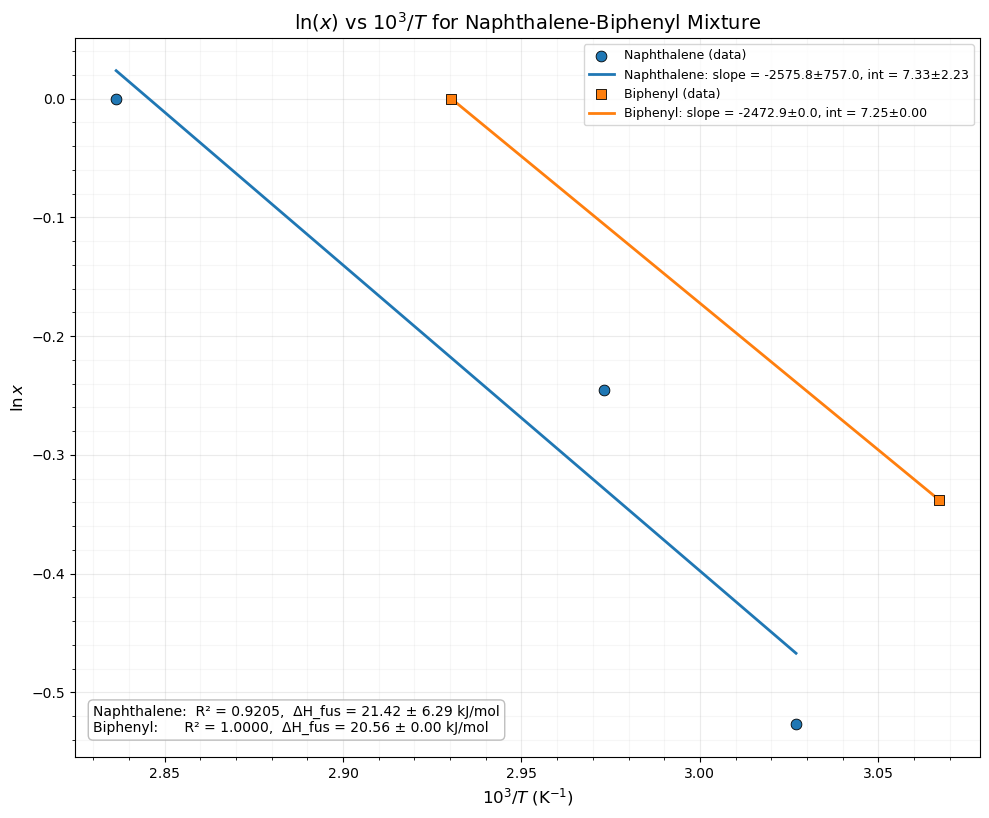

In [52]:
# Plot: ln(x) vs 1/T for naphthalene and biphenyl (with linear fits & uncertainties)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- 1. Re-run linregress to capture the full result objects for standard errors ---
# (This ensures we have access to intercept_stderr available in SciPy >= 1.6.0)
res_A = linregress(df_A['inv_T'], df_A['ln_XA'])
res_B = linregress(df_B['inv_T'], df_B['ln_XB'])

err_slope_A = res_A.stderr
err_int_A = getattr(res_A, 'intercept_stderr', 0.0)
err_dH_A = err_slope_A * R / 1000  # Propagate error to ΔH in kJ/mol

err_slope_B = res_B.stderr
err_int_B = getattr(res_B, 'intercept_stderr', 0.0)
err_dH_B = err_slope_B * R / 1000  # Propagate error to ΔH in kJ/mol (Note: will be 0.0 for N=2)

# --- helper: compute fit line in "10^3/T" units for nicer axis numbers ---
def fit_line_in_invT_mK(inv_T_min, inv_T_max, slope, intercept, n=200):
    x_invT_mK = np.linspace(inv_T_min, inv_T_max, n) * 1e3  # 10^3/T (K^-1)
    y = slope * (x_invT_mK / 1e3) + intercept               # slope defined for 1/T in K^-1
    return x_invT_mK, y

# Fit lines 
xA_line, yA_line = fit_line_in_invT_mK(df_A['inv_T'].min(), df_A['inv_T'].max(), res_A.slope, res_A.intercept)
xB_line, yB_line = fit_line_in_invT_mK(df_B['inv_T'].min(), df_B['inv_T'].max(), res_B.slope, res_B.intercept)

# Data points (also in 10^3/T units)
xA_pts = df_A['inv_T'].to_numpy() * 1e3
yA_pts = df_A['ln_XA'].to_numpy()
xB_pts = df_B['inv_T'].to_numpy() * 1e3
yB_pts = df_B['ln_XB'].to_numpy()

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter with visible edges
ax.scatter(xA_pts, yA_pts, s=60, marker='o', edgecolor='k', linewidth=0.6,
           label='Naphthalene (data)', zorder=3)
ax.plot(xA_line, yA_line, linewidth=2.0, label='Naphthalene (fit)')

ax.scatter(xB_pts, yB_pts, s=60, marker='s', edgecolor='k', linewidth=0.6,
           label='Biphenyl (data)', zorder=3)
ax.plot(xB_line, yB_line, linewidth=2.0, label='Biphenyl (fit)')

ax.set_xlabel(r'$10^3/T\;\mathrm{(K^{-1})}$', fontsize=12)
ax.set_ylabel(r'$\ln x$', fontsize=12)

# Light grid + minor ticks for readability
ax.minorticks_on()
ax.grid(True, which='major', alpha=0.25)
ax.grid(True, which='minor', alpha=0.10)

# Annotate fit quality & derived ΔH with UNCERTAINTIES
txt = (
    f"Naphthalene:  R² = {res_A.rvalue**2:.4f},  ΔH_fus = {DeltaH_A/1000:.2f} ± {err_dH_A:.2f} kJ/mol\n"
    f"Biphenyl:      R² = {res_B.rvalue**2:.4f},  ΔH_fus = {DeltaH_B/1000:.2f} ± {err_dH_B:.2f} kJ/mol"
)
ax.text(0.02, 0.03, txt, transform=ax.transAxes, fontsize=10,
        va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.7'))

ax.legend(frameon=True)
fig.tight_layout()

# Show the linear regression slope and intercept WITH UNCERTAINTIES in the legend
handles, labels = ax.get_legend_handles_labels()
new_labels = []
for label in labels:
    if label == 'Naphthalene (fit)':
        new_labels.append(f"Naphthalene: slope = {res_A.slope:.1f}±{err_slope_A:.1f}, int = {res_A.intercept:.2f}±{err_int_A:.2f}")
    elif label == 'Biphenyl (fit)':
        new_labels.append(f"Biphenyl: slope = {res_B.slope:.1f}±{err_slope_B:.1f}, int = {res_B.intercept:.2f}±{err_int_B:.2f}")
    else:
        new_labels.append(label)
        
ax.legend(handles, new_labels, frameon=True, loc='upper right', fontsize=9)

# Set title
ax.set_title(r'$\ln(x)$ vs $10^3/T$ for Naphthalene-Biphenyl Mixture', fontsize=14)

# Save high-resolution figure for LaTeX
fig.savefig('lnX_vs_invT.png', dpi=300, bbox_inches='tight')
plt.show()

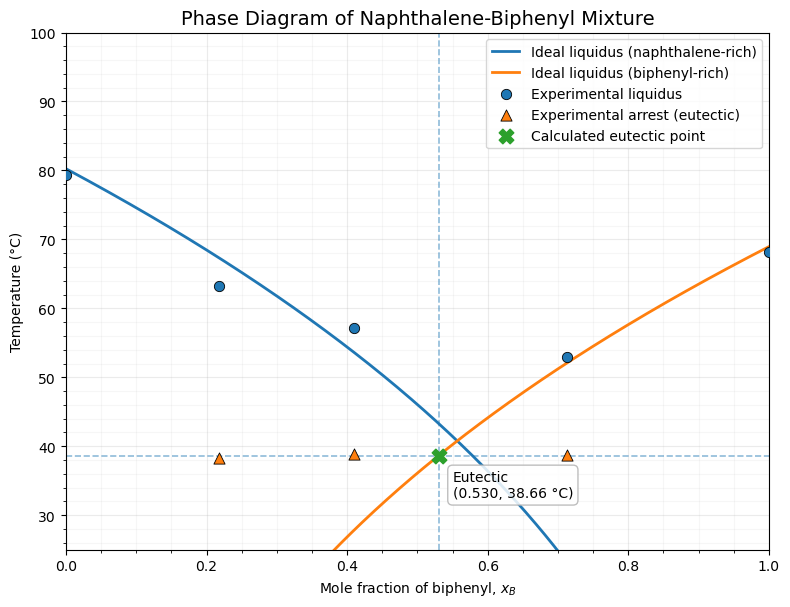

In [53]:
# Plot: ideal + experimental phase diagram (naphthalene–biphenyl)
import numpy as np
import matplotlib.pyplot as plt

R = 8.314  # J/(mol*K)

# Ideal liquidus curves from van't Hoff equation using LITERATURE parameters
x_B = np.linspace(1e-3, 1 - 1e-3, 400)

T_A_ideal = 1 / (1/T_A_0_lit - (R/DeltaH_A_lit) * np.log(1 - x_B))  # naphthalene-rich liquidus
T_B_ideal = 1 / (1/T_B_0_lit - (R/DeltaH_B_lit) * np.log(x_B))      # biphenyl-rich liquidus

# Convert to °C for plotting
T_A_ideal_C = T_A_ideal - 273.15
T_B_ideal_C = T_B_ideal - 273.15

# Experimental points:
# - liquidus temperatures (T_liq_K) for all runs in df_res
# - arrest/eutectic temperatures (T_eut) for mixture runs (A2, A3, B2), stored in data_points
liq_xB = df_res['XB'].to_numpy()
liq_T_C = (df_res['T_liq_K'] - 273.15).to_numpy()

arrest_xB, arrest_T_C = [], []
for run_name, d in data_points.items():
    if d.get('T_eut', None) is not None:
        # find composition for this run from df_res
        xB_run = float(df_res.loc[df_res['Run'] == run_name, 'XB'].values[0])
        arrest_xB.append(xB_run)
        arrest_T_C.append(d['T_eut'])  # already in °C from earlier analysis

arrest_xB = np.array(arrest_xB) if len(arrest_xB) else np.array([])
arrest_T_C = np.array(arrest_T_C) if len(arrest_T_C) else np.array([])

fig, ax = plt.subplots(figsize=(8, 6))

# Ideal curves (solid)
ax.plot(x_B, T_A_ideal_C, linewidth=2.0, label='Ideal liquidus (naphthalene-rich)')
ax.plot(x_B, T_B_ideal_C, linewidth=2.0, label='Ideal liquidus (biphenyl-rich)')

# Experimental points (liquidus & arrest)
ax.scatter(liq_xB, liq_T_C, s=55, marker='o', edgecolor='k', linewidth=0.6,
           label='Experimental liquidus', zorder=3)
if arrest_xB.size:
    ax.scatter(arrest_xB, arrest_T_C, s=65, marker='^', edgecolor='k', linewidth=0.6,
               label='Experimental arrest (eutectic)', zorder=4)

# Eutectic point from calculations
ax.scatter([XB_E], [T_E_K - 273.15], s=110, marker='X',
           label='Calculated eutectic point', zorder=5)

# Optional: visual guide lines at eutectic
ax.axvline(XB_E, linestyle='--', linewidth=1.2, alpha=0.5)
ax.axhline(T_E_K - 273.15, linestyle='--', linewidth=1.2, alpha=0.5)

ax.set_xlabel(r'Mole fraction of biphenyl, $x_B$')
ax.set_ylabel('Temperature (°C)')
ax.set_xlim(0, 1)

# Choose y-range based on data + a small margin (keeps figure robust if data changes)
y_min = min(np.min(T_A_ideal_C), np.min(T_B_ideal_C), np.min(liq_T_C)) - 5
y_max = max(np.max(T_A_ideal_C), np.max(T_B_ideal_C), np.max(liq_T_C)) + 5
ax.set_ylim(y_min, y_max)

# Label the eutectic point with its composition and temperature
ax.annotate(f'Eutectic\n({XB_E:.3f}, {T_E_K - 273.15:.2f} °C)',
            xy=(XB_E, T_E_K - 273.15), xycoords='data',
            xytext=(10, -30), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.7'))

ax.minorticks_on()
ax.grid(True, which='major', alpha=0.25)
ax.grid(True, which='minor', alpha=0.10)
ax.set_ylim(25,100)
ax.legend(frameon=True, loc='best')
fig.tight_layout()
ax.set_title('Phase Diagram of Naphthalene-Biphenyl Mixture', fontsize=14)
fig.savefig('phase_diagram.png', dpi=300, bbox_inches='tight')
plt.show()